In [6]:
#Abertura das Bibliotecas utilizadas
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import netCDF4 as nc
import plotly.express as px
import plotly.graph_objects as go
import cartopy.crs as ccrs # Escolha do sistema de coordenadas
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import matplotlib.patches as mpatches # Desenhar geometria em um mapa
import matplotlib.ticker as mticker
import rasterio

In [24]:
import rasterio
#Abre os dados de latitude e longitude
latlon_raster = rasterio.open("latlonERA5.tif").read()#Latitude e longitude
latlon_raster.shape

(2, 750, 551)

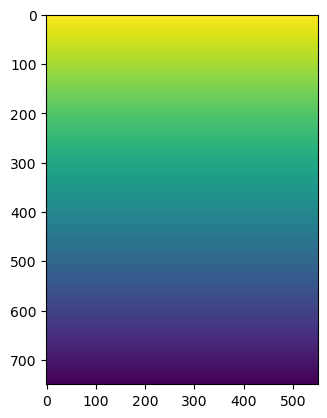

In [25]:
import matplotlib.pyplot as plt

#Visualização de variação da variável
plt.imshow(latlon_raster[1])#Latitude 

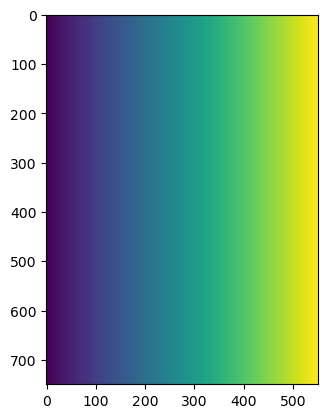

In [26]:
import matplotlib.pyplot as plt

#Visualização de variação da variável
plt.imshow(latlon_raster[0])#longitude

In [27]:
import numpy as np
import pandas as pd

# Remover duplicados
latitudes_unicas = pd.Series(latlon_raster[1].flatten()).drop_duplicates().tolist()
latitudes_unicas = np.round(latitudes_unicas,2)
print("latitude", len(latitudes_unicas))

# Remover duplicados
longitudes_unicas = pd.Series(latlon_raster[0].flatten()).drop_duplicates().tolist()
longitudes_unicas  = np.round(longitudes_unicas ,2)
print("longitude", len(longitudes_unicas))

latitude 750
longitude 551


In [1]:
import rasterio
#Abre o arquivo de Tmax tif.
Precip_Chirps = rasterio.open("Arquivos/precipitacao_Chirps.tif").read()
print('Precip_Chirps',Precip_Chirps.shape)

# Separa os valores do shape
mesesChirp, latitudeChirp, longitudeChirp = Precip_Chirps.shape

# Imprime os valores separados
print('Número de dados de tempo:', mesesChirp)
print('Número de latitudes:', latitudeChirp)
print('Número de longitudes:', longitudeChirp)

Precip_Chirps (519, 751, 551)
Número de dados de tempo: 519
Número de latitudes: 751
Número de longitudes: 551


In [2]:
# Dados de Tempo ERA5-Land
import numpy as np

#Definição da data inicial
data_inicialChirps=np.datetime64('1981-01', 'M')

#Criação de uma lista com as datas mensais - levando em consideração o número de linha de tempo presentes nos dados
data_Chirps = np.arange(data_inicialChirps,data_inicialChirps+mesesChirp, dtype="datetime64[M]")

data_Chirps = np.array(data_Chirps, dtype="datetime64[ns]") 
print("Dados de tempo:",data_Chirps.shape)
data_Chirps[:10]

Dados de tempo: (519,)


array(['1981-01-01T00:00:00.000000000', '1981-02-01T00:00:00.000000000',
       '1981-03-01T00:00:00.000000000', '1981-04-01T00:00:00.000000000',
       '1981-05-01T00:00:00.000000000', '1981-06-01T00:00:00.000000000',
       '1981-07-01T00:00:00.000000000', '1981-08-01T00:00:00.000000000',
       '1981-09-01T00:00:00.000000000', '1981-10-01T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [5]:
import rasterio
import numpy as np

# Abrir o arquivo .tif
with rasterio.open("Arquivos/precipitacao_Chirps.tif") as src:
    # Ler os dados da imagem (3D - Tempo, Latitude, Longitude)
    precip_data = src.read()

    # Obter a transformação espacial (informações de georreferenciamento)
    transform = src.transform

    # Obter os limites geográficos do arquivo
    bounds = src.bounds

    # Obter as dimensões da imagem (dimensões lat, lon)
    height = src.height
    width = src.width

    # Obter as coordenadas de latitude e longitude
    # O arquivo tem 3 dimensões (tempo, latitude, longitude), então vamos pegar as latitudes e longitudes
    latitudes_Chirps = np.linspace(bounds[1], bounds[3], height)  # De baixo para cima
    longitudes_Chirps = np.linspace(bounds[0], bounds[2], width)  # Da esquerda para a direita

# Imprimir informações sobre o arquivo e as coordenadas
print("Informações do arquivo .tif:")
print(f"Transformação: {transform}")
print(f"Limites: {bounds}")
print(f"Dimensões: {precip_data.shape}")

print("Primeiras 5 latitudes:", len(latitudes_Chirps))
print("Primeiras 5 longitudes:",len(longitudes_Chirps))

# Exibir a coordenada de latitude e longitude correspondentes ao primeiro valor de tempo, latitude e longitude
print("Primeiro valor de precipitação (na posição 0, 0):", precip_data[0, 0, 0])  # Tempo, Latitude, Longitude


Informações do arquivo .tif:
Transformação: | 0.10, 0.00,-85.05|
| 0.00,-0.10, 15.05|
| 0.00, 0.00, 1.00|
Limites: BoundingBox(left=-85.05000000000001, bottom=-60.05000000000001, right=-29.95000000000001, top=15.049999999999997)
Dimensões: (519, 751, 551)
Primeiras 5 latitudes: 751
Primeiras 5 longitudes: 551
Primeiro valor de precipitação (na posição 0, 0): 63.01915172368241


In [15]:
#Abertura do Arquivo Tmax
PPT_ERA = xr.open_dataset("Dados_tmin_tmax//PPT_ERA_01_1980-02_2024.nc")

# Acessar a variável 'Tmax'
PPT_ERA_base = PPT_ERA['PPT_ERA']
PPT_ERA_base
mascara = PPT_ERA_base.sel(time=slice('1981-01-01', None))
mascara

display(mascara)

<xarray.DataArray 'PPT_ERA' (time: 518, lat: 750, lon: 551)> Size: 2GB
[214063500 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2024-02-01
  * lat      (lat) float64 6kB 14.95 14.85 14.75 14.65 ... -59.75 -59.85 -59.95
  * lon      (lon) float64 4kB -84.95 -84.85 -84.75 ... -30.15 -30.05 -29.95

In [24]:
import xarray as xr
# Criação do DataArray
PPT_Chirps = xr.Dataset(
    {
       "PPT_Chirps": (["time", "lat", "lon"], Precip_Chirps) 
    },
    coords={
        "time": data_Chirps,  # A nova dimensão representa os anos
        "lat": latitudes_Chirps,
        "lon": longitudes_Chirps
    }
)


#Adicionando atributos
PPT_Chirps.attrs = {
    'title':'Precipitação Mensal Total - Chirps',
    'description':'Precipitação acumuluda por mês',
    'units': 'mm/mês',
    'source': 'Chirps',
    'institution': 'NOAA Climate Data Record (CDR)',
    'creator': 'Arthur Thomas Luz, Orientadores: Profa. Dra. Luciana Rizzo, Dr.Felipe Silva, Prof. Dr. Luiz Augusto Toledo Machado ', 
    'year': '1981 - 2024',
    'geospatial_bounds': 'Oeste: -85°, Sul: -60°, Leste: -30°, Norte: 15°',
    'spatial_resolution': '0.1° x 0.1°',
    'temporal_resolution': 'Mensal',
    'history': 'Criado em 20/03/2025 com base nos dados Persiann baixados pela Earth Engine',
    'references': 'https://pubs.usgs.gov/ds/691/ds691.pdf'
}

# Visualização dos dados
display(PPT_Chirps)
#PPT_Chirps.to_netcdf("Dados_tmin_tmax//PPT_Chirps_01_1981-03_2024.nc")

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 519, lat: 751, lon: 551)
Coordinates:
  * time        (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2024-03-01
  * lat         (lat) float64 6kB -60.05 -59.95 -59.85 ... 14.85 14.95 15.05
  * lon         (lon) float64 4kB -85.05 -84.95 -84.85 ... -30.15 -30.05 -29.95
Data variables:
    PPT_Chirps  (time, lat, lon) float64 2GB 63.02 65.77 68.53 ... nan nan nan
Attributes:
    title:                Precipitação Mensal Total - Chirps
    description:          Precipitação acumuluda por mês
    units:                mm/mês
    source:               Chirps
    institution:          NOAA Climate Data Record (CDR)
    creator:              Arthur Thomas Luz, Orientadores: Profa. Dra. Lucian...
    year:                 1981 - 2024
    geospatial_bounds:    Oeste: -85°, Sul: -60°, Leste: -30°, Norte: 15°
    spatial_resolution:   0.1° x 0.1°
    temporal_resolution:  Mensal
    history:              Criado em 20/03/2025 com base nos dados Persiann ba...
    references:           https://pubs.usgs.gov/ds/691/ds691.pdf

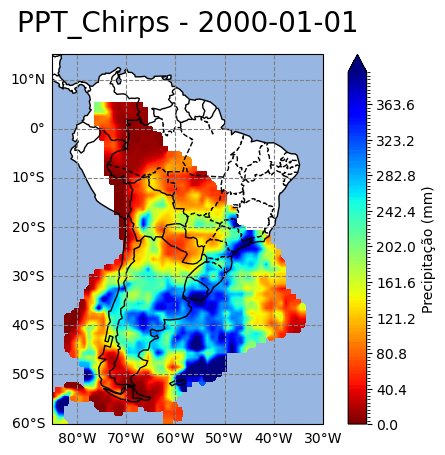

In [7]:
#Criando Mapa de Temperatura Anual média
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs # Escolha do sistema de coordenadas
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import xarray as xr
import cartopy.feature as cfeature

#***********************************************************************************************
Dado = PPT_Chirps
var = 'PPT_Chirps'
data ='2000-01-01'
#***********************************************************************************************

# Configurar o plot
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
               
Base = Dado[var].sel(time=data) 
# Plotar a média da temperatura
Base.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='jet_r',levels=np.linspace(0, 400, 100), cbar_kwargs={'label': 'Precipitação (mm)'})
#levels=np.linspace(10, 30, 21) é utilizado para definir que a colorBar vai de 10° C até 30°, tendo 21 ponto 


#Adicionando o contorno dos continentes, países e estados do Brasil
#Adicionando o contorno dos continentes
ax.add_feature(cfeature.COASTLINE)

#Adicionando os limites dos países
ax.add_feature(cfeature.BORDERS)

#Adicionando o oceano
ax.add_feature(cfeature.OCEAN)

#Adicionando os limites estaduais
states = cfeature.NaturalEarthFeature(category='cultural',
                                      name='admin_1_states_provinces_lines',
                                      scale='50m',
                                      facecolor='none')
ax.add_feature(states, edgecolor='k', linestyle='--')

#Adicionando título a figura 
ax.set_title(f'{var} - {data}', fontsize=20, y=1.04)

#Adicionando as linhas de grade
g1 = ax.gridlines(crs=ccrs.PlateCarree(), linestyle='--', color='gray', draw_labels=True)

#Formatando os labels como latitude e longitude
g1.yformatter = LATITUDE_FORMATTER
g1.xformatter = LONGITUDE_FORMATTER

#agora irei tirar as grades  superior e direita
# Remove as linhas de grade à direita
g1.ylabels_right = False  # Remove labels do eixo y à direita
g1.right_labels = False  # Remove a linha de grade à direita
g1.y_inline = False  # Evita que as linhas de grade internas sejam desenhadas

# Remove as linhas de grade no topo (se necessário)
g1.xlabels_top = False  # Remove labels do eixo x no topo

# Remove as linhas de grade no topo (se necessário)
g1.xlabels_top = False  # Remove labels do eixo x no topo
g1.top_labels = False  # Remove a linha de grade no topo